# Explorative Datenanalyse (EDA) & Preprocessing - Woche 1

In diesem Notebook führen wir alle vorbereitenden Schritte für unser Data Science Projekt durch. Wir verbinden uns mit der Datenbank, reinigen die Daten (Outlier & negative Werte) und erstellen die grundlegenden Datensätze (`session_base.csv` und `not_canceled_trips.csv`), welche wir in Woche 2 für das Feature Engineering verwenden.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Einstellungen für Plots
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 1. Verbindung zur Datenbank & Daten laden

Wir nutzen unsere `.env` Datei, um die Zugangsdaten sicher zu laden. 
Gleichzeitig filtern wir direkt im SQL auf unsere **Kohorte** (alle Nutzer ab dem `2023-01-04`) und beheben per `ABS(nights)` erste Fehler bei den negativen Nächten.

In [2]:
# Lade Umgebungsvariablen (z.B. DATABASE_URL)
load_dotenv()
db_connection_str = os.getenv('DATABASE_URL')

# Korrigiere postgres:// zu postgresql:// für SQLAlchemy, falls nötig
if db_connection_str and db_connection_str.startswith("postgres://"):
    db_connection_str = db_connection_str.replace("postgres://", "postgresql://", 1)

# Wir definieren, wie viele Reihen wir laden wollen. Hier z.B. 100.000 (oder wir können das LIMIT in SQL entfernen für alle).
engine = create_engine(db_connection_str)
sample_size = 150000

query = f"""
WITH CohortUsers AS (
    SELECT user_id 
    FROM sessions 
    WHERE session_start >= '2023-01-04'
            GROUP BY user_id
            HAVING COUNT(session_id) > 7
)
SELECT 
    s.session_id,
    s.user_id,
    s.trip_id,
    s.session_start,
    s.session_end,
    s.flight_discount,
    s.hotel_discount,
    s.flight_discount_amount,
    s.hotel_discount_amount,
    s.flight_booked,
    s.hotel_booked,
    s.page_clicks,
    s.cancellation,
    f.origin_airport,
    f.destination,
    f.destination_airport,
    f.seats,
    f.return_flight_booked,
    f.departure_time,
    f.return_time,
    f.checked_bags,
    f.trip_airline,
    f.destination_airport_lat,
    f.destination_airport_lon,
    f.base_fare_usd,
    h.hotel_name,
    -- Negative Nächte behandeln (aus z.B. -2 wird 2)
    ABS(h.nights) AS nights,
    h.rooms,
    h.check_in_time,
    h.check_out_time,
            h.hotel_per_room_usd,
            u.birthdate,
            u.gender,
            u.married,
            u.has_children,
            u.home_country,
            u.home_city,
            u.home_airport
FROM sessions s
JOIN CohortUsers cu ON s.user_id = cu.user_id
LEFT JOIN flights f ON s.trip_id = f.trip_id
LEFT JOIN hotels h ON s.trip_id = h.trip_id
        LEFT JOIN users u ON s.user_id = u.user_id
LIMIT {sample_size};
"""

df = pd.read_sql(query, engine)
print(f"Daten geladen: {df.shape[0]} Reihen und {df.shape[1]} Spalten gefunden!")

Daten geladen: 150000 Reihen und 31 Spalten gefunden!


## 2. Erste EDA und Data Cleaning (Ausreißer)
Wir überprüfen, ob wir Extremwerte haben und decken sie ("Clipping").

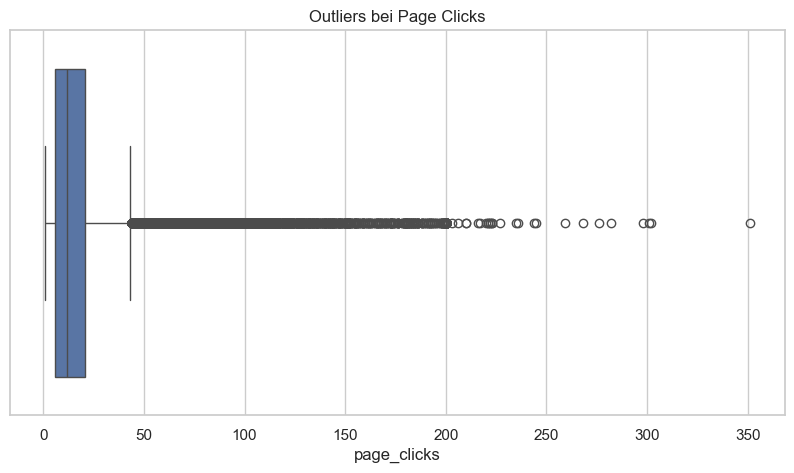

In [3]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['page_clicks'])
plt.title('Outliers bei Page Clicks')
plt.show()

### Explorative Datenanalyse (Histogramme)
Um ein Gefühl für die Verteilung unserer Nutzer zu bekommen, betrachten wir drei Kern-Metriken: Page Clicks, Nächte pro Reise und Hotel-Preis pro Nacht.

In [ ]:
# --- Visualisierungen für df ---
print("\n--- Erstelle Visualisierungen für df ---")

# Abbildung 1: Verteilungs-Plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Verteilung der Session-Metriken', fontsize=16)

# Histogramm für Page Clicks
sns.histplot(df['page_clicks'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Verteilung der Page Clicks')
axes[0, 0].set_xlabel('Page Clicks')
axes[0, 0].set_ylabel('Anzahl der Sessions')

# Histogramm für gebuchte Nächte
sns.histplot(df['nights'], bins=10, kde=False, ax=axes[0, 1])
axes[0, 1].set_title('Verteilung der gebuchten Nächte')
axes[0, 1].set_xlabel('Nächte')
axes[0, 1].set_ylabel('Anzahl der Sessions')

# Histogramm für Flugpreis (Base Fare)
sns.histplot(df['base_fare_usd'].dropna(), bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Verteilung des Flugpreises (USD)')
axes[1, 0].set_xlabel('Flugpreis (USD)')
axes[1, 0].set_ylabel('Anzahl der Sessions')

# Histogramm für Hotelpreis pro Zimmer/Nacht
sns.histplot(df['hotel_per_room_usd'].dropna(), bins=20, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Verteilung von Hotelpreis pro Zimmer/Nacht (USD)')
axes[1, 1].set_xlabel('Hotelpreis (USD)')
axes[1, 1].set_ylabel('Anzahl der Sessions')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Abbildung 2: Kategorische Count-Plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.suptitle('Buchungs- und Rabatt-Status', fontsize=16)

# Count-Plot für Flug- und Hotelbuchungen
booked_df = df[['flight_booked', 'hotel_booked']].melt(var_name='Booking Type', value_name='Booked')
sns.countplot(x='Booking Type', hue='Booked', data=booked_df, ax=axes[0])
axes[0].set_title('Flug vs. Hotel gebucht')
axes[0].set_xlabel('Buchungstyp')
axes[0].set_ylabel('Anzahl')

# Count-Plot für Flug- und Hotelrabatte
discount_df = df[['flight_discount', 'hotel_discount']].melt(var_name='Discount Type', value_name='Applied')
sns.countplot(x='Discount Type', hue='Applied', data=discount_df, ax=axes[1])
axes[1].set_title('Flug vs. Hotel Rabatt angewendet')
axes[1].set_xlabel('Rabatttyp')
axes[1].set_ylabel('Anzahl')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Abbildung 3: Beziehungs-Plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.suptitle('Beziehungen in den Session-Daten', fontsize=16)

# Scatter-Plot: Page Clicks vs. Flugpreis
sns.scatterplot(x='page_clicks', y='base_fare_usd', data=df, ax=axes[0])
axes[0].set_title('Page Clicks vs. Flugpreis (USD)')
axes[0].set_xlabel('Page Clicks')
axes[0].set_ylabel('Flugpreis (USD)')

# Box-Plot: Flugpreis nach Buchungsstatus
sns.boxplot(x='flight_booked', y='base_fare_usd', data=df, ax=axes[1], showfliers=False)
axes[1].set_title('Flugpreis pro Buchungsstatus (Outlier ausgeblendet)')
axes[1].set_xlabel('Flug gebucht')
axes[1].set_ylabel('Flugpreis (USD)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
# Ausreißer in 'base_fare_usd' & 'page_clicks' behandeln
# Negative Base Fares auf 0 beschränken
df['base_fare_usd'] = df['base_fare_usd'].apply(lambda x: max(0, x) if pd.notnull(x) else x)

# Extreme "page_clicks"-Werte am 99%-Perzentil "cappen"
Q1 = df['page_clicks'].quantile(0.25)
Q3 = df['page_clicks'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"Das 99te Perzentil der Page Clicks liegt bei {percentile_99_clicks}. Alle Werte darüber werden nun geglättet.")

df['page_clicks'] = df['page_clicks'].clip(upper=upper_bound)


Das 99te Perzentil der Page Clicks liegt bei 95.0. Alle Werte darüber werden nun geglättet.


## 3. Speichern der Ziel-Datensätze
Wir erzeugen nun `session_base.csv` für jede Menge Interaktionsdaten (für Storno-Features etc.) und `not_canceled_trips.csv` für spezifische Reisendaten.

In [5]:
os.makedirs('../data', exist_ok=True)

# session_base.csv exportieren
session_base_cols = [
    'session_id', 'user_id', 'trip_id', 'session_start', 'session_end',
    'flight_discount', 'hotel_discount', 'flight_discount_amount', 
    'hotel_discount_amount', 'flight_booked', 'hotel_booked', 
            'page_clicks', 'cancellation',
            'birthdate', 'gender', 'married', 'has_children',
            'home_country', 'home_city', 'home_airport'
]
session_base = df[session_base_cols].copy()
session_path = '../data/session_base.csv'
session_base.to_csv(session_path, index=False)

# not_canceled_trips.csv exportieren
not_canceled = df[
    (df['cancellation'] == False) & 
    (df['flight_booked'] | df['hotel_booked']) & 
    (df['trip_id'].notnull())
].copy()

# --- Zusätzliche Fehlerbehandlung für angetretene Reisen ---
print("Vor Fehlerbehebung in Reisendaten...")

# A. Vertauschte Check-in / Check-out Zeiten tauschen (Hotel)
not_canceled["check_in_time"] = pd.to_datetime(not_canceled["check_in_time"])
not_canceled["check_out_time"] = pd.to_datetime(not_canceled["check_out_time"])

mask_swapped = not_canceled["check_out_time"] < not_canceled["check_in_time"]
if mask_swapped.sum() > 0:
    print(f"- Korrigiere {mask_swapped.sum()} vertauschte Check-In/Check-Out Daten.")
    temp_checkin = not_canceled.loc[mask_swapped, "check_in_time"].copy()
    not_canceled.loc[mask_swapped, "check_in_time"] = not_canceled.loc[mask_swapped, "check_out_time"]
    not_canceled.loc[mask_swapped, "check_out_time"] = temp_checkin

# B. 0 Nächte trotz Hotelbuchung auf mindestens 1 setzen
mask_0_nights = (not_canceled["hotel_booked"] == True) & (not_canceled["nights"] == 0)
if mask_0_nights.sum() > 0:
    print(f"- Korrigiere {mask_0_nights.sum()} Hotelbuchungen mit 0 Nächten zu 1.")
    not_canceled.loc[mask_0_nights, "nights"] = 1

# C. 0 Sitze trotz Flugbuchung auf mindestens 1 setzen
mask_0_seats = (not_canceled["flight_booked"] == True) & (not_canceled["seats"] == 0)
if mask_0_seats.sum() > 0:
    print(f"- Korrigiere {mask_0_seats.sum()} Flugbuchungen mit 0 Sitzen zu 1.")
    not_canceled.loc[mask_0_seats, "seats"] = 1

not_canceled_path = '../data/not_canceled_trips.csv'
not_canceled.to_csv(not_canceled_path, index=False)

print(f"Gespeichert: {session_path} (Sessions/Interaktionen, {len(session_base)} Zeilen)")
print(f"Gespeichert: {not_canceled_path} (Nur angetretene Reisen, {len(not_canceled)} Zeilen)")

Gespeichert: ../data/session_base.csv (Sessions/Interaktionen, 150000 Zeilen)
Gespeichert: ../data/not_canceled_trips.csv (Nur angetretene Reisen, 41736 Zeilen)
